**Mini Project 1 - Evolutionary Algorithms for Constrained Optimization**

Project Theme : Evolve a weekly production plan


Problem Analysis 

Definition of given Input and Constraints


In [9]:
# Variables

Products = ["A", "B", "C"]

Days = [1, 2, 3, 4, 5]

TotalVariables = len(Products) * len(Days)

print("Total number of variables:", TotalVariables)

Xpd = [
    [10, 20, 20, 8, 20],  # A
    [5, 6, 8, 4, 5],     # B
    [3, 2, 6, 7, 5]      # C
]

profit = {"A": 6, "B": 5, "C": 8}

# Constraints

MachineTimeLimit = 120  # Maximum machine time available per day for all products

ProductionTime = {
    "A": 3,  # Time taken to produce one unit of product A
    "B": 2,  # Time taken to produce one unit of product B
    "C": 4   # Time taken to produce one unit of product C
}

CalcMachineTime = lambda x, product: ProductionTime[product] * x

MaterialCostLimit = 60 #Total material available per day for all products

MaterialCost = {
    "A": 2,  # Material cost per unit of product A 
    "B": 1,  # Material cost per unit of product B
    "C": 3   # Material cost per unit of product C
}

CalcMaterialCost = lambda x, product: MaterialCost[product] * x



WeeklyDemandCap = {
    "A": 60,  # Weekly demand for product A 
    "B": 80,  # Weekly demand for product B
    "C": 40   # Weekly demand for product C
}

NonLinearSetupCost_C = 20 # if C exceeds 8 units per day, a setup cost of 20 is incurred.

CalcNonLinearSetupCost_C = lambda x: NonLinearSetupCost_C if x > 8 else 0

#Evolutionary Algorithm is used for this problem because the problem involves multiple products, 
# constraints, and a non-linear setup cost for product C.


Total number of variables: 15


Encoding 1 
Genotype = Discrete values

Eg., Genotype = [[5,2,3,4,5],
[5,2,10,4,5],
[5,2,19,4,5]
] direct mapping of preoduction quatities of each product on each day

Phenotype = Direct mapping with Genotype

Phenotype = Genotype

In [10]:
#Initialize population Encoding1
import random

#Random genotype generator
def random_genotype_encoding1():
    return [[random.randint(0, 20) for _ in range(len(Days))] for _ in range(len(Products))]

#Population initialization
def initialize_population_encoding1(population_size):
    return [random_genotype_encoding1() for _ in range(population_size)]



Encoding 2 :

Genotype = Real numbers 

Example : genotype = [
    [0.25, 0.80, 0.60, 0.10, 0.95],
    [0.30, 0.45, 0.70, 0.50, 0.20],
    [0.15, 0.90, 0.40, 0.35, 0.60]
]

Phenotype (Decoded Production Plan)

Since production quantities must be integers between 0 and 20:

Phenotype = =|20 * Genotype|



In [11]:
#Encoding 2

import random

def random_individual_Encoding2():
    return [
        [random.uniform(0, 1) for _ in range(5)]
        for _ in range(3)
    ]

#Decode Genotype to Phenotype
def decode_real(genotype):
    phenotype = []

    for row in genotype:
        decoded_row = []

        for gene in row:
            production = int(gene * 20)
            decoded_row.append(production)

        phenotype.append(decoded_row)

    return phenotype



Approach 1 Penalty based fitness function Definitions for Encoding1

In [12]:

#Fitness funtion
#Approach A : Penalty method

#Violation of machine time constraint
def ViolationMachineTime(Xpd):
    violation = 0

    for d in range(len(Days)):

        used = (
            ProductionTime["A"] * Xpd[0][d]
            + ProductionTime["B"] * Xpd[1][d]
            + ProductionTime["C"] * Xpd[2][d]
        )

        violation += max(0, used - MachineTimeLimit)

    return violation

def ViolationMaterialCost(Xpd):
    violation = 0

    for d in range(len(Days)):

        used = (
            MaterialCost["A"] * Xpd[0][d]
            + MaterialCost["B"] * Xpd[1][d]
            + MaterialCost["C"] * Xpd[2][d]
        )

        violation += max(0, used - MaterialCostLimit)

    return violation

def Violationdemand(Xpd):
    violation = 0

    for i in range(len(Products)):
        product = Products[i]
        total_production = sum(Xpd[i])
        violation += max(0, total_production - WeeklyDemandCap[product])

    return violation

def TotalViolation(Xpd):
    return ViolationMachineTime(Xpd) + ViolationMaterialCost(Xpd) + Violationdemand(Xpd)


def Profit(Xpd):
    total_profit = 0
    for i in range(len(Products)):
        for j in range(len(Days)):
            product = Products[i]
            
            total_profit += Xpd[i][j] * profit[product]
    return total_profit
    
def SetupCost(Xpd):
    cost = 0

    c_index = Products.index("C")

    for d in range(5):
        if Xpd[c_index][d] > 8:
            cost += 20

    return cost

def NetProfit(Xpd):
    return Profit(Xpd) - SetupCost(Xpd)


Lambda = 100  # Penalty coefficient for constraint violation
def FitnessPenalty(Xpd):
    #print("Net Profit:", NetProfit(Xpd))
    #print("Total Violation:", TotalViolation(Xpd))
    fitness_value = NetProfit(Xpd) - Lambda * TotalViolation(Xpd)
    #print("Fitness value:", fitness_value)
    return fitness_value   

FitnessPenalty(Xpd)
#print("Fitness value:", FitnessPenalty(Xpd))

-1608

Approach 2 : Repair based function and its Fitness for Encoding1

In [13]:
def repair_constraints(genotype):
    for d in range(len(Days)):
        # Repair machine time constraint
        used_machine_time = (
            ProductionTime["A"] * genotype[0][d]
            + ProductionTime["B"] * genotype[1][d]
            + ProductionTime["C"] * genotype[2][d]
        )
        if used_machine_time > MachineTimeLimit:
            excess = used_machine_time - MachineTimeLimit
            for i in range(len(Products)):
                if excess <= 0:
                    break
                if genotype[i][d] > 0:
                    reduction = min(genotype[i][d], excess // ProductionTime[Products[i]])
                    genotype[i][d] -= reduction
                    excess -= reduction * ProductionTime[Products[i]]

        # Repair material cost constraint
        used_material_cost = (
            MaterialCost["A"] * genotype[0][d]
            + MaterialCost["B"] * genotype[1][d]
            + MaterialCost["C"] * genotype[2][d]
        )
        if used_material_cost > MaterialCostLimit:
            excess = used_material_cost - MaterialCostLimit
            for i in range(len(Products)):
                if excess <= 0:
                    break
                if genotype[i][d] > 0:
                    reduction = min(genotype[i][d], excess // MaterialCost[Products[i]])
                    genotype[i][d] -= reduction
                    excess -= reduction * MaterialCost[Products[i]]

    return genotype
def repair_demand_genotype(genotype):
    for i in range(len(Products)):
        product = Products[i]
        total_production = sum(genotype[i])
        if total_production > WeeklyDemandCap[product]:
            excess = total_production - WeeklyDemandCap[product]
            for j in range(len(Days)):
                if excess <= 0:
                    break
                if genotype[i][j] > 0:
                    reduction = min(genotype[i][j], excess)
                    genotype[i][j] -= reduction
                    excess -= reduction
    return genotype

#Fitness function with repair mechanism
def FitnessRepair(Xpd):
    #print("Original Genotype:", Xpd)
    repaired_Xpd = repair_constraints([row[:] for row in Xpd])  # Create a copy to avoid modifying the original
    repaired_Xpd = repair_demand_genotype(repaired_Xpd)  # Apply demand repair
    #print("Repaired Genotype:", repaired_Xpd)
    return NetProfit(repaired_Xpd)

FitnessRepair(Xpd)

684

Define selection Functions for Encoding 1 Penalty and Repair Based Fitness

In [ ]:


#Tournament selection
def TournamentEncoding1Penalty(population, k=3):
    selected = random.sample(population, k)
    #print("Selected genotypes for tournament:", selected)
    return max(selected, key=FitnessPenalty)

def TournamentEncoding1Repair(population, k=3):
    selected = random.sample(population, k)
    #print("Selected genotypes for tournament:", selected)
    return max(selected, key=FitnessRepair)
#tournament_selected = tournament_selection(initial_population)

#print("Selected genotype from tournament selection:", tournament_selected)
#print("Fitness of selected genotype:", FitnessPenalty(tournament_selected))


#Crossover
def crossover(parent1, parent2):
    child = []
    for i in range(len(Products)):
        crossover_point = random.randint(1, len(Days) - 1)
        child_row = parent1[i][:crossover_point] + parent2[i][crossover_point:]
        child.append(child_row) 
    return child

#Mutation
def mutate(genotype, mutation_rate=0.1):
    for i in range(len(Products)):
        for j in range(len(Days)):
            if random.random() < mutation_rate:
                
                genotype[i][j] = random.randint(0, 20)
                #print(f"Mutated gene at ({i}, {j}) from {old_value} to {genotype[i][j]}")
    return genotype


#Complete Genetic Algorithm Loop Penalty Encoding1
def run_genetic_algorithm_encoding1_penalty(population_size=100, generations=50, k=3):
    initial_population = initialize_population_encoding1(population_size)
    for generation in range(generations):  # Number of generations
        #print(f"Generation {generation + 1}")
        
        new_population = []
        while len(new_population) < len(initial_population):
            # Selection
            parent1 = TournamentEncoding1Penalty(initial_population, k)
            parent2 = TournamentEncoding1Penalty(initial_population, k)
            
            # Crossover
            child1 = crossover(parent1, parent2)
            
            # Mutation
            #print("Before mutation:", child1)
            child2 = mutate(child1)
            
            new_population.append(child2)
        
        initial_population = new_population
        # Print the best fitness in the current generation

    
    best_individual = max(new_population, key=FitnessPenalty)
    best_fitness = FitnessPenalty(best_individual)
    return best_individual, best_fitness


def run_genetic_algorithm_encoding1_repair(population_size=100, generations=50, k=3):
    initial_population = initialize_population_encoding1(population_size)
    for generation in range(generations):  # Number of generations
        #print(f"Generation {generation + 1}")
        
        new_population = []
        while len(new_population) < len(initial_population):
            # Selection
            parent1 = TournamentEncoding1Repair(initial_population, k)
            parent2 = TournamentEncoding1Repair(initial_population, k)
            
            # Crossover
            child1 = crossover(parent1, parent2)
            
            # Mutation
            child2 = mutate(child1)
            
            new_population.append(child2)
        
        initial_population = new_population
        # Print the best fitness in the current generation
    best_individual = max(new_population, key=FitnessRepair)
    best_fitness = FitnessRepair(best_individual)
    return best_individual, best_fitness

#run the genetic algorithm with penalty method
best_individual_penalty, best_fitness_penalty = run_genetic_algorithm_encoding1_penalty(population_size=100, generations=50)
print("Best individual (Penalty):", best_individual_penalty)
print("Best fitness (Penalty):", best_fitness_penalty)  

#run the genetic algorithm with repair method
best_individual_repair, best_fitness_repair = run_genetic_algorithm_encoding1_repair(population_size=100, generations=50)
print("Best individual (Repair):", best_individual_repair)
print("Best fitness (Repair):", best_fitness_repair)    


Best individual (Penalty): [[14, 7, 7, 17, 8], [11, 17, 19, 11, 19], [7, 8, 8, 5, 6]]
Best fitness (Penalty): 975
Best individual (Repair): [[12, 14, 19, 17, 18], [15, 17, 15, 20, 14], [7, 7, 8, 6, 8]]
Best fitness (Repair): 1024


Encoding 2
Define Fitness Functions for Encoding 2 Penalty and Repair
Re-use previous funtions with decoding

In [15]:
def Encoding2_FitnessPenalty(genotype):
    phenotype = decode_real(genotype)
    return FitnessPenalty(phenotype)


def Encoding2_FitnessRepair(genotype):
    phenotype = decode_real(genotype)
    return FitnessRepair(phenotype)

Define Selection functions for Encoding2 Penalty and Repair

In [16]:

def Encoding2_TournamentPenalty(population, k=3):

    contestants = random.sample(population, k)

    winner = max(
        contestants,
        key=Encoding2_FitnessPenalty
    )

    return winner

def Encoding2_TournamentRepair(population, k=3):

    contestants = random.sample(population, k)

    winner = max(
        contestants,
        key=Encoding2_FitnessRepair
    )

    return winner

def Encoding2_Crossover(parent1, parent2):
    child = []
    for i in range(len(Products)):
        row = []
        for j in range(len(Days)):
            if random.random() < 0.5:
                row.append(parent1[i][j])
            else:
                row.append(parent2[i][j])
        child.append(row)
         
    return child

def Encoding2_Mutate(genotype, mutation_rate=0.1):
    for i in range(len(Products)):
        for j in range(len(Days)):
            if random.random() < mutation_rate:
                genotype[i][j] = random.uniform(0, 1)
    return genotype



In [18]:
#Complete Genetic Algorithm Loop for Encoding 2

def run_genetic_algorithm_encoding2_repair(population_size=100, generations=50, mutation_rate=0.1, k=3):
    # Initialize population
    population = [random_individual_Encoding2() for _ in range(population_size)]
    best_history = []
    mean_history = []
    for generation in range(generations):
        #print(f"Generation {generation + 1}")
        new_population = []
        while len(new_population) < population_size:
            # Selection
            parent1 = Encoding2_TournamentRepair(population, k)
            parent2 = Encoding2_TournamentRepair(population, k)

            # Crossover
            child = Encoding2_Crossover(parent1, parent2)

            # Mutation
            child = Encoding2_Mutate(child, mutation_rate)

            new_population.append(child)

        population = new_population

        # Evaluate population
        fitnesses = [
            Encoding2_FitnessRepair(ind)
            for ind in population
        ]

        best_history.append(max(fitnesses))
        mean_history.append(sum(fitnesses) / len(fitnesses))

    best_individual = max(population, key=Encoding2_FitnessRepair)
    best_fitness = Encoding2_FitnessRepair(best_individual)
    return (
        best_individual,
        best_fitness,
        best_history,
        mean_history
    )

def run_genetic_algorithm_encoding2_penalty(population_size=100, generations=50, mutation_rate=0.1, k=3):
    # Initialize population
    population = [random_individual_Encoding2() for _ in range(population_size)]

    best_history = []
    mean_history = []

    for generation in range(generations):
       # print(f"Generation {#generation + 1}")
        new_population = []
        while len(new_population) < population_size:
            # Selection
            parent1 = Encoding2_TournamentPenalty(population, k)
            parent2 = Encoding2_TournamentPenalty(population, k)

            # Crossover
            child = Encoding2_Crossover(parent1, parent2)

            # Mutation
            child = Encoding2_Mutate(child, mutation_rate)

            new_population.append(child)

        population = new_population

        fitnesses = [
            Encoding2_FitnessPenalty(ind)
            for ind in population
        ]

        best_history.append(max(fitnesses))
        mean_history.append(sum(fitnesses) / len(fitnesses))

    best_individual = max(population, key=Encoding2_FitnessPenalty)
    best_fitness = Encoding2_FitnessPenalty(best_individual)

    return best_individual, best_fitness, best_history, mean_history

print("\nRunning Genetic Algorithm with Encoding 2 and Penalty Method...")
best_individual_penalty, best_fitness_penalty, penalty_best_history, penalty_mean_history = run_genetic_algorithm_encoding2_penalty()
print("Best Individual (Penalty):", best_individual_penalty)
print("Best Fitness (Penalty):", best_fitness_penalty)


print("Running Genetic Algorithm with Encoding 2 and Repair Mechanism...")
best_individual_repair, best_fitness_repair, repair_best_history, repair_mean_history = run_genetic_algorithm_encoding2_repair()
print("Best Individual (Repair):", best_individual_repair)
print("Best Fitness (Repair):", best_fitness_repair)    




Running Genetic Algorithm with Encoding 2 and Penalty Method...
Best Individual (Penalty): [[0.5499030566137931, 0.4734372675126557, 0.5660694127876397, 0.6568236602692269, 0.5405907142989181], [0.7631311784751117, 0.7275445159755299, 0.7244499604144453, 0.9630200990088522, 0.6409705301263828], [0.42255814413579484, 0.45078914737097275, 0.3019739214179257, 0.1575076098096413, 0.34765805778699277]]
Best Fitness (Penalty): 924
Running Genetic Algorithm with Encoding 2 and Repair Mechanism...
Best Individual (Repair): [[0.8889712713480954, 0.8552084481882346, 0.7326272221220064, 0.8492249977860884, 0.8391137993001071], [0.7666212398623287, 0.42926705599462867, 0.9235991510581406, 0.9583246591293385, 0.974391111099247], [0.3740923802134646, 0.4436666800515108, 0.43382949136600335, 0.39472125870849395, 0.291839740955829]]
Best Fitness (Repair): 1023


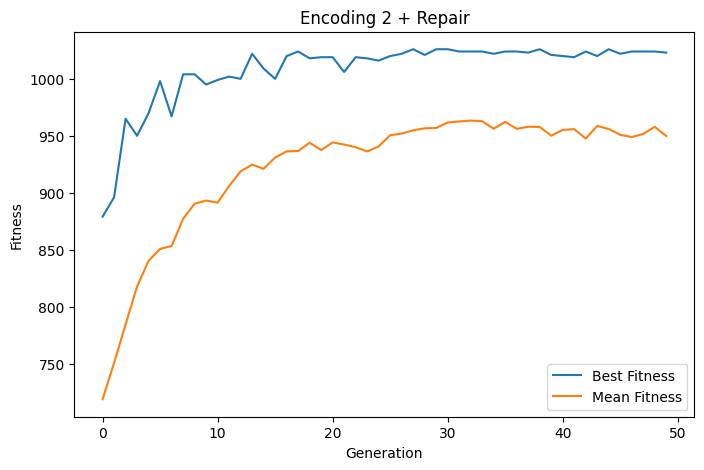

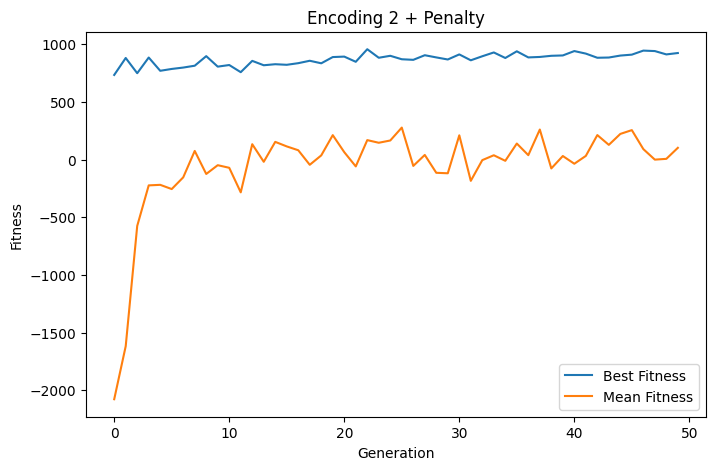

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    repair_best_history,
    label="Best Fitness"
)

plt.plot(
    repair_mean_history,
    label="Mean Fitness"
)

plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.title("Encoding 2 + Repair")
plt.legend()

plt.show()

#Penalty

plt.figure(figsize=(8,5))

plt.plot(
    penalty_best_history,
    label="Best Fitness"
)

plt.plot(
    penalty_mean_history,
    label="Mean Fitness"
)

plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.title("Encoding 2 + Penalty")
plt.legend()

plt.show()